In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver


from langchain_huggingface import HuggingFaceEndpoint
from langchain_huggingface.chat_models import ChatHuggingFace
from dotenv import load_dotenv
import os

/home/aminul/anaconda3/envs/spector/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

# Initialize HuggingFace LLM
llm = HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation",
    huggingfacehub_api_token=os.getenv("HUGGINGFACE_API_KEY")
)

model = ChatHuggingFace(llm=llm)

In [3]:
class jokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [17]:
def generateJoke(state: jokeState):
    prompt = f"Tell me a joke about {state['topic']}."
    response = model.invoke([HumanMessage(content=prompt)])
    
    return {'joke': response}

In [18]:
def explainJoke(state: jokeState):
    prompt = f"Explain the following joke: {state['joke']}"
    response = model.invoke([HumanMessage(content=prompt)])
    
    return {'explanation': response}

In [19]:
graph = StateGraph(jokeState)


graph.add_node('generateJoke', generateJoke)
graph.add_node('explainJoke', explainJoke)


graph.add_edge(START, 'generateJoke')
graph.add_edge('generateJoke', 'explainJoke')
graph.add_edge('explainJoke', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

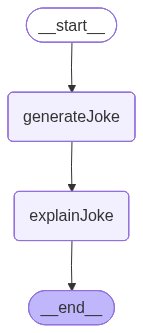

In [20]:
workflow

In [21]:
config = {"configurable": {'thread_id': "1"}}

workflow.invoke({'topic': 'computers'}, config  = config)

{'topic': 'computers',
 'joke': AIMessage(content='Why do computers never get cold?\n\nBecause they’ve got *bytes* to keep them warm! 🖥️❄️', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 78, 'total_tokens': 136}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_07c3a8857b', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--dc83a252-f8a0-402e-9edd-e6a9281b981b-0', usage_metadata={'input_tokens': 78, 'output_tokens': 58, 'total_tokens': 136}),
 'explanation': AIMessage(content='**The joke**\n\n> *Why do computers never get cold?*  \n> *Because they’ve got **bytes** to keep them warm!* 🖥️❄️  \n\n**Why it’s funny**\n\n1. **Wordplay (pun)**  \n   - The punchline hinges on the homophonic relationship between **“bytes”** (a unit of digital information, 8\u202fbits) and **“bites”** (the act of chewing or the sensation of something cold “biting” you).  \n   - In everyday language, we might say something “bites” when it fee

In [22]:
workflow.get_state(config)

StateSnapshot(values={'topic': 'computers', 'joke': AIMessage(content='Why do computers never get cold?\n\nBecause they’ve got *bytes* to keep them warm! 🖥️❄️', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 78, 'total_tokens': 136}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_07c3a8857b', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--dc83a252-f8a0-402e-9edd-e6a9281b981b-0', usage_metadata={'input_tokens': 78, 'output_tokens': 58, 'total_tokens': 136}), 'explanation': AIMessage(content='**The joke**\n\n> *Why do computers never get cold?*  \n> *Because they’ve got **bytes** to keep them warm!* 🖥️❄️  \n\n**Why it’s funny**\n\n1. **Wordplay (pun)**  \n   - The punchline hinges on the homophonic relationship between **“bytes”** (a unit of digital information, 8\u202fbits) and **“bites”** (the act of chewing or the sensation of something cold “biting” you).  \n   - In everyday language, we might say something 

In [23]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'computers', 'joke': AIMessage(content='Why do computers never get cold?\n\nBecause they’ve got *bytes* to keep them warm! 🖥️❄️', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 78, 'total_tokens': 136}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_07c3a8857b', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--dc83a252-f8a0-402e-9edd-e6a9281b981b-0', usage_metadata={'input_tokens': 78, 'output_tokens': 58, 'total_tokens': 136}), 'explanation': AIMessage(content='**The joke**\n\n> *Why do computers never get cold?*  \n> *Because they’ve got **bytes** to keep them warm!* 🖥️❄️  \n\n**Why it’s funny**\n\n1. **Wordplay (pun)**  \n   - The punchline hinges on the homophonic relationship between **“bytes”** (a unit of digital information, 8\u202fbits) and **“bites”** (the act of chewing or the sensation of something cold “biting” you).  \n   - In everyday language, we might say something

# Time Travel

In [38]:
workflow.get_state(
    config = {
       "configurable": {
        'thread_id': '1',
        'checkpoint_id': "1f0cf804-96e3-61f8-8000-a61e438a4e8d"
        }
    }
)

StateSnapshot(values={'topic': 'computers'}, next=('generateJoke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f0cf804-96e3-61f8-8000-a61e438a4e8d'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-12-02T13:10:34.320732+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0cf804-96e1-6364-bfff-1ffacc4d0a96'}}, tasks=(PregelTask(id='708584f0-b918-d348-03bc-48e245989de0', name='generateJoke', path=('__pregel_pull', 'generateJoke'), error=None, interrupts=(), state=None, result={'joke': AIMessage(content='Why do computers never get cold?\n\nBecause they’ve got *bytes* to keep them warm! 🖥️❄️', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 78, 'total_tokens': 136}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_07c3a8857b', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--dc83a252-f8a0-402e-9edd-e6a9281b981b-0', usage_metadat

In [39]:
workflow.invoke(None,
        config = {
            "configurable": {
            'thread_id': '1',
            'checkpoint_id': "1f0cf804-96e3-61f8-8000-a61e438a4e8d"
            }
        }
    )

{'topic': 'computers',
 'joke': AIMessage(content='Sure, here’s one for you:\n\nWhy do programmers prefer dark mode?\n\nBecause light attracts bugs!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 78, 'total_tokens': 130}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c5da83ab22', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--49d7c962-4b30-4447-9a08-d8ba2f7231c1-0', usage_metadata={'input_tokens': 78, 'output_tokens': 52, 'total_tokens': 130}),
 'explanation': AIMessage(content='**What the joke is saying**\n\n> *Why do programmers prefer dark mode?*  \n> *Because light attracts bugs!*\n\nThe humor comes from a play on two different meanings of the word **“bugs.”**  \n\n| Meaning of “bugs” | Why it fits the punch‑line |\n|-------------------|---------------------------|\n| **Software bugs** – errors or flaws in code that cause a program to behave incorrectly. | Programmers spend a lot of time hunting down (a

In [40]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'computers', 'joke': AIMessage(content='Sure, here’s one for you:\n\nWhy do programmers prefer dark mode?\n\nBecause light attracts bugs!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 78, 'total_tokens': 130}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c5da83ab22', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--49d7c962-4b30-4447-9a08-d8ba2f7231c1-0', usage_metadata={'input_tokens': 78, 'output_tokens': 52, 'total_tokens': 130}), 'explanation': AIMessage(content='**What the joke is saying**\n\n> *Why do programmers prefer dark mode?*  \n> *Because light attracts bugs!*\n\nThe humor comes from a play on two different meanings of the word **“bugs.”**  \n\n| Meaning of “bugs” | Why it fits the punch‑line |\n|-------------------|---------------------------|\n| **Software bugs** – errors or flaws in code that cause a program to behave incorrectly. | Programmers spend a lot of 

In [41]:
workflow.update_state(
    config={
        "configurable": {
            "thread_id": "1",
            "checkpoint_id": "1f0cf804-96e3-61f8-8000-a61e438a4e8d",
            "checkpoint_ns": ""
        }
    },
    values={
        "topic": "samosa"
    }
)


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0cf8ad-c09d-6c00-8001-c5f09fe1e8e0'}}

In [42]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'topic': 'samosa'}, next=('generateJoke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0cf8ad-c09d-6c00-8001-c5f09fe1e8e0'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2025-12-02T14:26:15.255338+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0cf804-96e3-61f8-8000-a61e438a4e8d'}}, tasks=(PregelTask(id='23c78da7-3bb6-f338-016f-90e7374a9e8f', name='generateJoke', path=('__pregel_pull', 'generateJoke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'computers', 'joke': AIMessage(content='Sure, here’s one for you:\n\nWhy do programmers prefer dark mode?\n\nBecause light attracts bugs!', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 78, 'total_tokens': 130}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c5da83ab22', 'finish_re

In [44]:
workflow.invoke(None,
        config = {
            "configurable": {
            'thread_id': '1',
            'checkpoint_id': "1f0cf8a8-0685-668e-8001-3a67e7735d99"
            }
        }
    )

{'topic': 'samosa',
 'joke': AIMessage(content='Why did the samosa go to therapy?\n\nBecause it was feeling *crumby* on the outside but had a lot of *stuff* going on inside! 😄', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 79, 'total_tokens': 147}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_029931c09b', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--42828849-295c-439c-9ca1-84e87ef93f5e-0', usage_metadata={'input_tokens': 79, 'output_tokens': 68, 'total_tokens': 147}),
 'explanation': AIMessage(content='**The joke broken down**\n\n> *Why did the samosa go to therapy?*  \n> *Because it was feeling **crumby** on the outside but had a lot of **stuff** going on inside! 😄*\n\n---\n\n### 1. What a samosa is\nA samosa is a popular fried (or baked) snack in many South‑Asian cuisines. It’s a triangular pastry that’s **crispy on the outside** and **filled with a mixture of spiced vegetables, meat, or lentils** on t